# ESG Thesis — Preliminary Exploratory Data Analysis

**Author:** Thomas Nguyen · **Date:** March 2026

**Topic:** Machine learning to identify ESG rating inconsistencies and improve portfolio outcomes.

**Data:** Yahoo Finance / Sustainalytics ESG scores via `yfinance`. Scores are scraped in real time, so values may vary slightly between runs. For ~100 tickers, expect several minutes for downloads.

**Setup (once):** `pip install yfinance pandas numpy matplotlib seaborn tqdm scikit-learn`

Run cells in order from top to bottom.


## 0. Imports and settings


In [9]:
import warnings
warnings.filterwarnings("ignore")

import logging
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import time
import os
from io import BytesIO
import urllib.request

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUTPUT_DIR = "outputs/eda"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("ESG THESIS — Preliminary EDA")
print("=" * 70)


ESG THESIS — Preliminary EDA


## 1. Universe — S&P 500 tickers and sectors

Load the current S&P 500 list from Wikipedia (ticker symbols normalized for Yahoo).


In [10]:
print("\n[1/6] Fetching S&P 500 universe from Wikipedia...")

def get_sp500():
    # Wikipedia returns 403 without a descriptive User-Agent (blocks default urllib/pandas).
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": (
                "ThesisESGResearch/1.0 (MSc thesis EDA; Python; pandas) "
                "https://meta.wikimedia.org/wiki/User-Agent_policy"
            ),
        },
    )
    with urllib.request.urlopen(req, timeout=60) as resp:
        html = resp.read()
    df = pd.read_html(BytesIO(html))[0]
    df.columns = df.columns.str.strip()
    df["Symbol"] = df["Symbol"].str.replace(".", "-", regex=False)
    df = df.rename(columns={
        "Symbol": "ticker",
        "Security": "company",
        "GICS Sector": "sector",
        "GICS Sub-Industry": "sub_industry",
        "Date added": "date_added",
    })
    return df[["ticker", "company", "sector", "sub_industry"]]

sp500 = get_sp500()
print(f"  Universe: {len(sp500)} companies across {sp500['sector'].nunique()} sectors")
print(sp500["sector"].value_counts().to_string())



[1/6] Fetching S&P 500 universe from Wikipedia...
  Universe: 503 companies across 11 sectors
sector
Industrials               79
Financials                76
Information Technology    73
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22


## 2. ESG scores

**Yahoo / `yfinance`:** Sustainalytics-style fields used to come from the `quoteSummary` module `esgScores`. As of 2025–2026 Yahoo often returns **404** or drops that module, so `.sustainability` is empty even when `.info` still works. This is a provider/API change, not bad tickers.

**What to do:**
- **`ESG_SOURCE = "yahoo"`** — still tries Yahoo (may return no rows).
- **`ESG_SOURCE = "csv"`** — load scores from a file you provide (e.g. vendor export, Kaggle, WRDS). Set `ESG_CSV_PATH`.
- **`ESG_SOURCE = "synthetic"`** — **demo only**: plausible random scores by sector so the rest of the notebook runs.

Adjust `MAX_TICKERS` for a quick test vs. full universe.


In [11]:
# --- ESG input (see markdown above) ---
ESG_SOURCE = "yahoo"       # "yahoo" | "csv" | "synthetic"
ESG_CSV_PATH = None        # e.g. "data/external/esg_scores.csv" when ESG_SOURCE == "csv"
ESG_FALLBACK_SYNTHETIC = True   # if Yahoo returns 0 rows, use synthetic with a loud warning

MAX_TICKERS = 100          # e.g. 50 for quick test, 503 for full S&P 500
SLEEP_BETWEEN = 0.3        # seconds between requests

tickers_to_download = sp500["ticker"].tolist()[:MAX_TICKERS]


In [12]:
def _normalize_ticker(s):
    return str(s).strip().upper().replace(".", "-")


def load_esg_from_csv(path, tickers_list, sp500_df):
    """CSV columns: ticker (or symbol), esg_total, esg_env, esg_soc, esg_gov; optional controversy."""
    raw = pd.read_csv(path)
    lower = {c.lower().strip(): c for c in raw.columns}
    tic_key = next((k for k in ("ticker", "symbol", "tic") if k in lower), None)
    if tic_key is None:
        raise ValueError("ESG CSV needs a ticker column named ticker, symbol, or tic.")
    raw = raw.rename(columns={lower[tic_key]: "ticker"})
    raw["ticker"] = raw["ticker"].map(_normalize_ticker)
    cols_lower = {c.lower().strip() for c in raw.columns}
    need = {"esg_total", "esg_env", "esg_soc", "esg_gov"}
    missing = need - cols_lower
    if missing:
        raise ValueError(f"ESG CSV missing columns: {missing}. Expected esg_total, esg_env, esg_soc, esg_gov.")
    colmap = {c: c.lower().strip() for c in raw.columns}
    raw = raw.rename(columns=colmap)
    raw = raw.set_index("ticker")
    if "controversy" not in raw.columns:
        raw["controversy"] = np.nan
    extra = sp500_df.set_index("ticker")[["sector", "company"]]
    out = raw.join(extra, how="inner")
    out = out[out.index.isin(tickers_list)]
    return out


def synthetic_esg_for_tickers(sp500_df, tickers_list, seed=42):
    """Demo-only ESG-like scores (not real Sustainalytics data)."""
    rng = np.random.default_rng(seed)
    sub = sp500_df.set_index("ticker").reindex(tickers_list).dropna(subset=["sector"]).reset_index()
    sec_ids, _ = pd.factorize(sub["sector"])
    base = 22 + sec_ids.astype(float) * 2.5
    noise = rng.normal(0, 6, len(sub))
    sub["esg_total"] = np.clip(base + noise, 5, 55)
    sub["esg_env"] = np.clip(sub["esg_total"] + rng.normal(0, 4, len(sub)), 3, 60)
    sub["esg_soc"] = np.clip(sub["esg_total"] + rng.normal(0, 4, len(sub)), 3, 60)
    sub["esg_gov"] = np.clip(sub["esg_total"] + rng.normal(0, 4, len(sub)), 3, 60)
    sub["controversy"] = rng.integers(0, 4, len(sub))
    return sub.set_index("ticker")[["esg_total", "esg_env", "esg_soc", "esg_gov", "controversy", "sector", "company"]]


print("\n[2/6] Loading ESG scores...")

if ESG_SOURCE == "csv":
    if not ESG_CSV_PATH:
        raise ValueError("Set ESG_CSV_PATH when ESG_SOURCE is 'csv'.")
    esg = load_esg_from_csv(ESG_CSV_PATH, tickers_to_download, sp500)
    print(f"  ESG from CSV: {len(esg)} tickers")

elif ESG_SOURCE == "synthetic":
    print("  WARNING: using SYNTHETIC ESG scores — for pipeline demo only, not for thesis results.")
    esg = synthetic_esg_for_tickers(sp500, tickers_to_download)
    print(f"  Synthetic ESG rows: {len(esg)}")

else:
    # Yahoo: suppress per-ticker 404 spam from yfinance logger
    _yf_log = logging.getLogger("yfinance")
    _prev_level = _yf_log.level
    _yf_log.setLevel(logging.CRITICAL)
    esg_records = []
    failed_yf = []
    for ticker in tqdm(tickers_to_download, desc="ESG (Yahoo)"):
        try:
            t = yf.Ticker(ticker)
            sust = t.sustainability
            if sust is not None and not sust.empty:
                row = sust.T.iloc[0].to_dict()
                row["ticker"] = ticker
                esg_records.append(row)
            else:
                failed_yf.append(ticker)
        except Exception:
            failed_yf.append(ticker)
        time.sleep(SLEEP_BETWEEN)
    _yf_log.setLevel(_prev_level)

    if len(esg_records) == 0:
        msg = (
            "Yahoo returned no ESG data (common when esgScores is omitted from quoteSummary). "
            "Use ESG_SOURCE='csv' with your own file, or ESG_SOURCE='synthetic' for a demo."
        )
        if ESG_FALLBACK_SYNTHETIC:
            warnings.warn(msg + " Falling back to synthetic ESG.", UserWarning)
            print("  WARNING: ESG_FALLBACK_SYNTHETIC=True — using synthetic scores.")
            esg = synthetic_esg_for_tickers(sp500, tickers_to_download)
        else:
            raise RuntimeError(msg)
    else:
        esg_raw = pd.DataFrame(esg_records).set_index("ticker")
        core_cols = {
            "totalEsg":           "esg_total",
            "environmentScore":   "esg_env",
            "socialScore":        "esg_soc",
            "governanceScore":    "esg_gov",
            "highestControversy": "controversy",
            "esgPerformance":     "esg_performance_label",
        }
        available = {k: v for k, v in core_cols.items() if k in esg_raw.columns}
        esg = esg_raw[list(available.keys())].rename(columns=available)
        esg = esg.apply(pd.to_numeric, errors="coerce")
        esg = esg.join(sp500.set_index("ticker")[["sector", "company"]])
        print(f"  ESG from Yahoo: {len(esg)} tickers (no row: {len(failed_yf)})")

print(f"\n  ESG Score Summary (lower = better risk on Sustainalytics-style scale where applicable):")
print(esg[["esg_total", "esg_env", "esg_soc", "esg_gov", "controversy"]].describe().round(2))



[2/6] Loading ESG scores...


ESG (Yahoo): 100%|██████████| 100/100 [07:41<00:00,  4.62s/it]


  ESG Score Summary (lower = better risk on Sustainalytics-style scale where applicable):
       esg_total  esg_env  esg_soc  esg_gov  controversy
count     100.00   100.00   100.00   100.00       100.00
mean       30.82    30.78    30.57    31.23         1.46
std         8.46     9.65     9.36     9.38         1.19
min        14.38     9.95     7.09     9.62         0.00
25%        24.40    23.97    24.36    24.24         0.00
50%        29.95    30.29    29.12    30.52         2.00
75%        37.39    36.81    38.70    37.46         3.00
max        48.25    50.34    57.69    54.67         3.00


## 3. Financial fundamentals

Pull `info` fields for each ticker that has ESG data, then add derived ratios.


In [13]:
print("\n[3/6] Downloading financial fundamentals...")

fund_records = []

for ticker in tqdm(esg.index.tolist(), desc="Fundamentals"):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        row = {
            "ticker":        ticker,
            "market_cap":    info.get("marketCap"),
            "revenue":       info.get("totalRevenue"),
            "net_income":    info.get("netIncomeToCommon"),
            "total_assets":  info.get("totalAssets"),
            "total_debt":    info.get("totalDebt"),
            "ebitda":        info.get("ebitda"),
            "roe":           info.get("returnOnEquity"),
            "roa":           info.get("returnOnAssets"),
            "profit_margin": info.get("profitMargins"),
            "debt_equity":   info.get("debtToEquity"),
            "current_ratio": info.get("currentRatio"),
            "beta":          info.get("beta"),
            "pe_ratio":      info.get("trailingPE"),
            "pb_ratio":      info.get("priceToBook"),
            "employees":     info.get("fullTimeEmployees"),
        }
        fund_records.append(row)
        time.sleep(SLEEP_BETWEEN)
    except Exception:
        pass

fund = pd.DataFrame(fund_records).set_index("ticker")
fund["log_market_cap"] = np.log(fund["market_cap"].clip(lower=1))
fund["leverage"]       = fund["total_debt"] / (fund["total_assets"].clip(lower=1))
fund["profit_margin"]  = fund["profit_margin"].clip(-1, 1)

print(f"  Fundamentals retrieved for {fund.dropna(subset=['market_cap']).shape[0]} tickers")
print(fund[["log_market_cap", "leverage", "roa", "profit_margin", "beta"]].describe().round(3))



[3/6] Downloading financial fundamentals...


Fundamentals: 100%|██████████| 100/100 [01:03<00:00,  1.58it/s]

  Fundamentals retrieved for 100 tickers
       log_market_cap      roa  profit_margin     beta
count         100.000  100.000        100.000  100.000
mean           24.714    0.067          0.141    1.040
std             1.386    0.062          0.127    0.567
min            22.604   -0.020         -0.474   -0.064
25%            23.666    0.029          0.069    0.667
50%            24.600    0.050          0.143    1.010
75%            25.501    0.090          0.209    1.314
max            28.928    0.395          0.608    3.673


## 4. Master dataset

Inner join ESG and fundamentals; require non-missing total ESG score.


In [14]:
print("\n[4/6] Building master dataset...")

df = esg.join(fund, how="inner")
df = df.dropna(subset=["esg_total"])

print(f"  Master dataset: {df.shape[0]} firms x {df.shape[1]} variables")
print(f"  Sectors: {df['sector'].nunique()}")



[4/6] Building master dataset...
  Master dataset: 100 firms x 24 variables
  Sectors: 11


## 5. Exploratory data analysis

Figures are saved under `outputs/eda/`. Run the following cells in order.


### 5.1 Missing data



[5/6] Running EDA — generating plots...


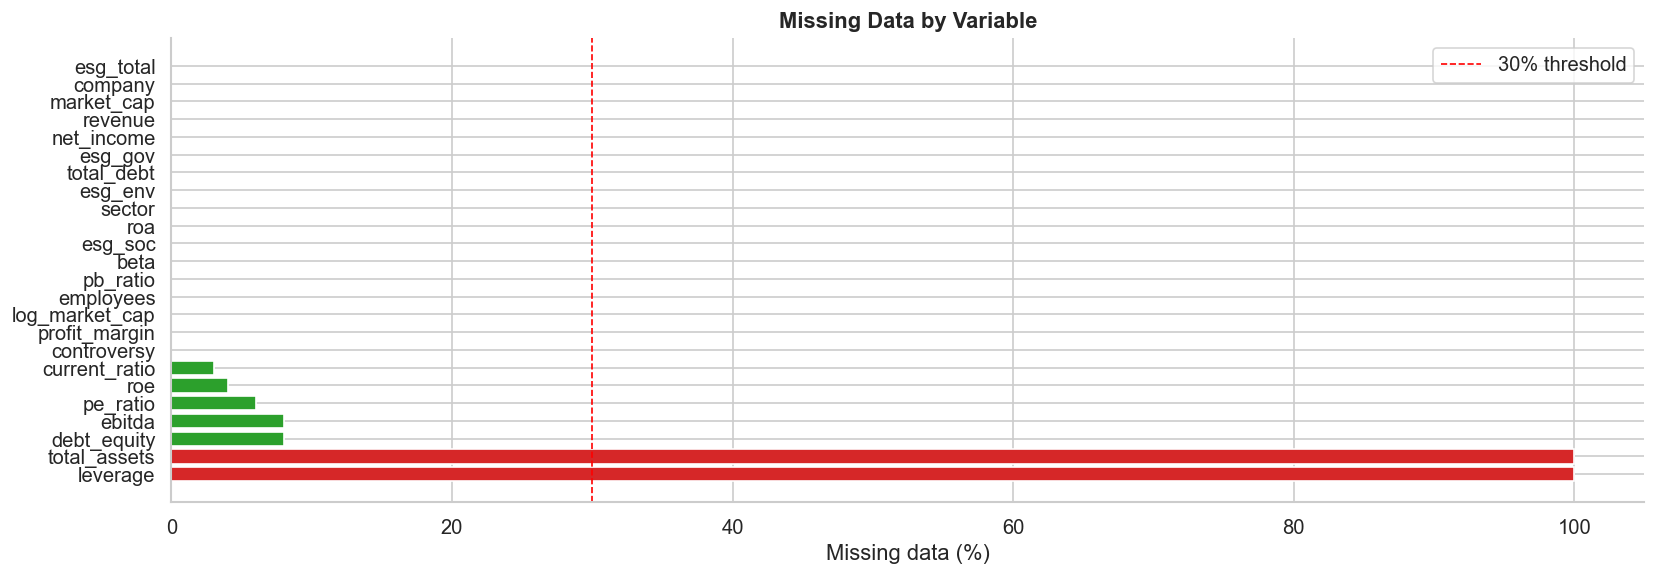

  → Saved: 01_missing_data.png


In [15]:
print("\n[5/6] Running EDA — generating plots...")

fig, ax = plt.subplots(figsize=(14, 5))
miss = df.isnull().mean().sort_values(ascending=False)
ax.barh(miss.index, miss.values * 100, color=["#d62728" if v > 0.3 else "#2ca02c" for v in miss.values])
ax.set_xlabel("Missing data (%)")
ax.set_title("Missing Data by Variable", fontweight="bold")
ax.axvline(30, color="red", linestyle="--", linewidth=1, label="30% threshold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_missing_data.png")
plt.show()
print("  → Saved: 01_missing_data.png")


### 5.2 ESG score distributions


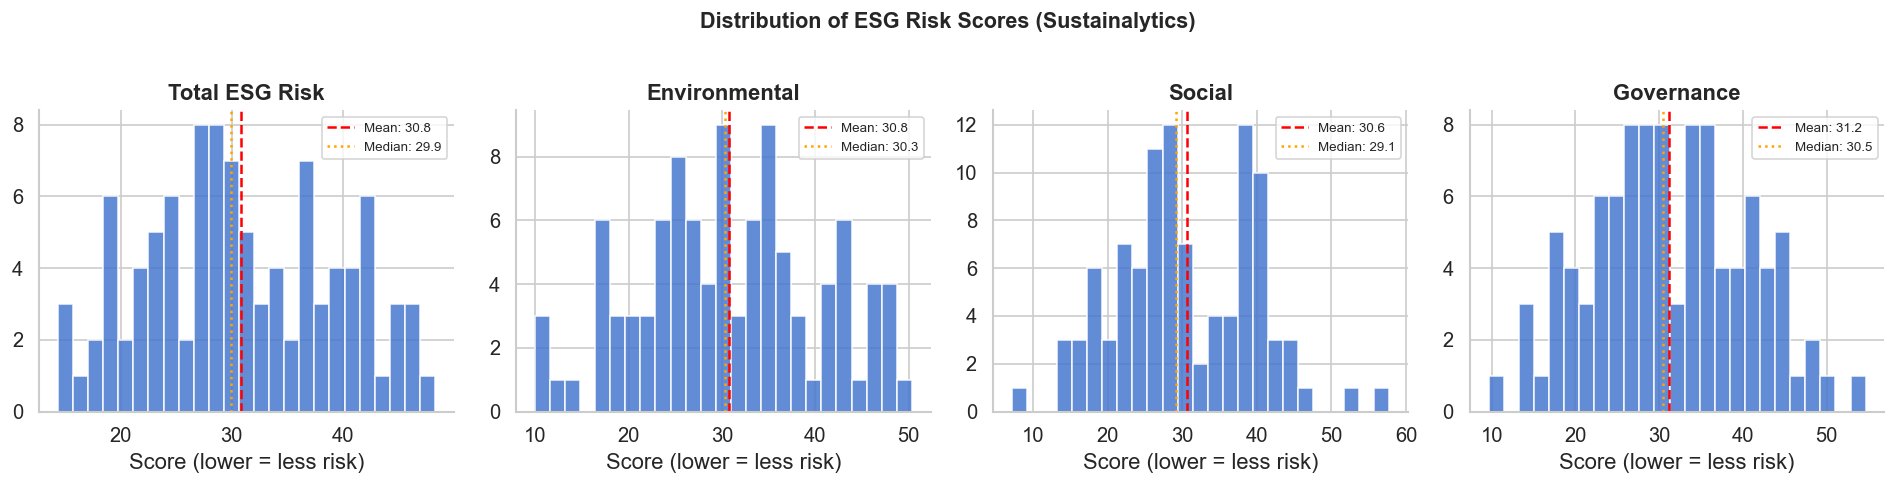

  → Saved: 02_esg_distributions.png


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
esg_cols = [("esg_total", "Total ESG Risk"), ("esg_env", "Environmental"),
            ("esg_soc", "Social"), ("esg_gov", "Governance")]

for ax, (col, label) in zip(axes, esg_cols):
    if col in df.columns:
        ax.hist(df[col].dropna(), bins=25, color="#4878CF", edgecolor="white", alpha=0.85)
        ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5,
                   label=f"Mean: {df[col].mean():.1f}")
        ax.axvline(df[col].median(), color="orange", linestyle=":", linewidth=1.5,
                   label=f"Median: {df[col].median():.1f}")
        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Score (lower = less risk)")
        ax.legend(fontsize=8)

plt.suptitle("Distribution of ESG Risk Scores (Sustainalytics)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_esg_distributions.png", bbox_inches="tight")
plt.show()
print("  → Saved: 02_esg_distributions.png")


### 5.3 ESG by sector


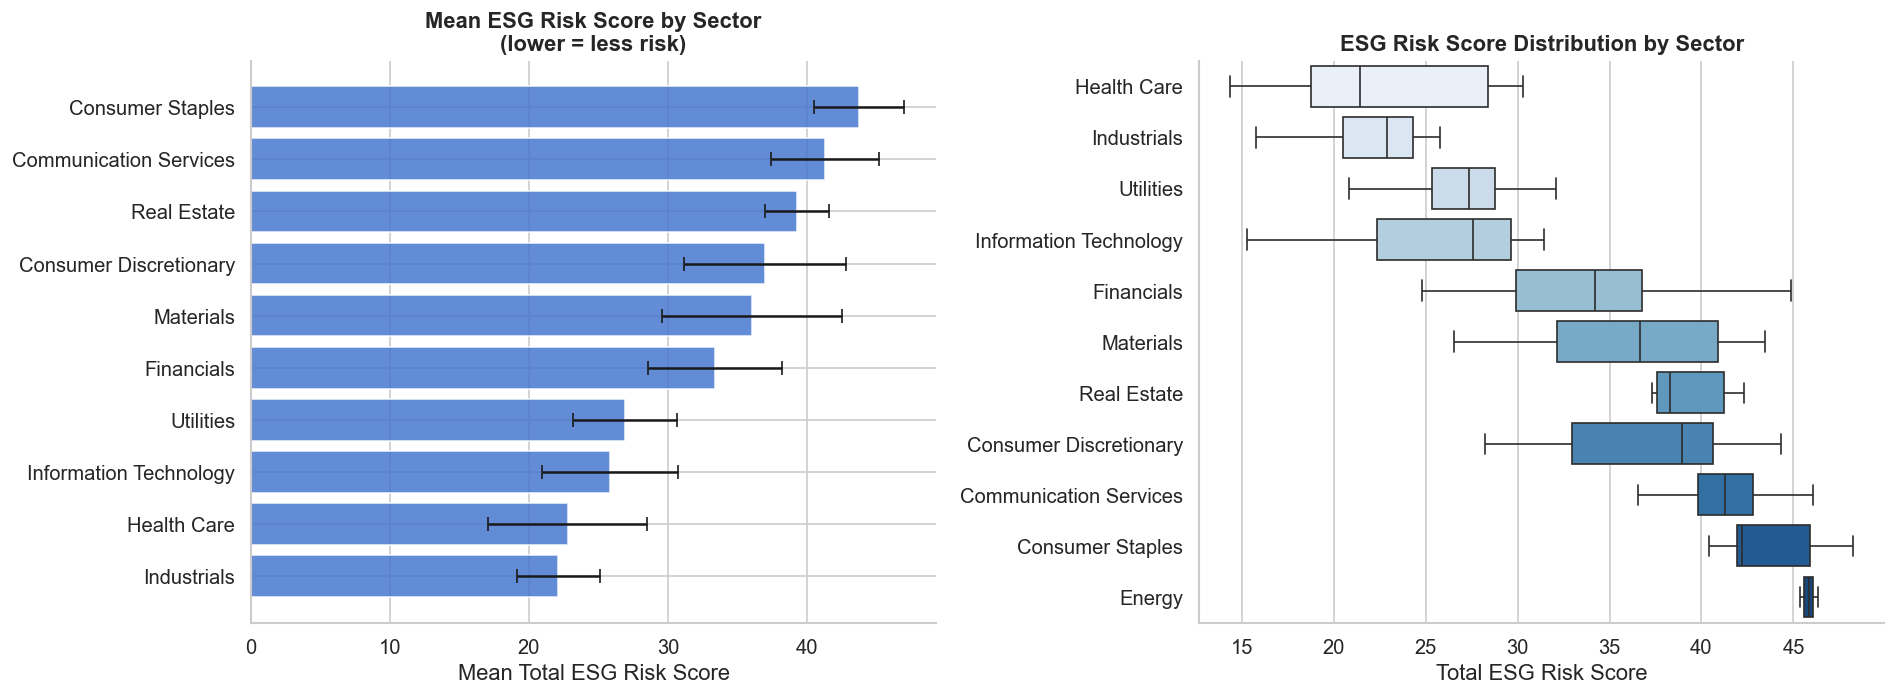

  → Saved: 03_esg_by_sector.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sector_esg = df.groupby("sector")["esg_total"].agg(["mean", "std", "count"]).sort_values("mean")
sector_esg = sector_esg[sector_esg["count"] >= 3]

axes[0].barh(sector_esg.index, sector_esg["mean"],
             xerr=sector_esg["std"], capsize=4,
             color="#4878CF", alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Mean Total ESG Risk Score")
axes[0].set_title("Mean ESG Risk Score by Sector\n(lower = less risk)", fontweight="bold")

sector_order = df.groupby("sector")["esg_total"].median().sort_values().index.tolist()
df_plot = df[df["sector"].isin(sector_order)].copy()
sns.boxplot(data=df_plot, y="sector", x="esg_total", order=sector_order,
            palette="Blues", ax=axes[1])
axes[1].set_xlabel("Total ESG Risk Score")
axes[1].set_ylabel("")
axes[1].set_title("ESG Risk Score Distribution by Sector", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_esg_by_sector.png", bbox_inches="tight")
plt.show()
print("  → Saved: 03_esg_by_sector.png")


### 5.4 ESG vs. firm size and fundamentals


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_vars = [
    ("log_market_cap", "Log Market Cap", "esg_total"),
    ("leverage",       "Leverage (D/A)", "esg_total"),
    ("roa",            "Return on Assets", "esg_total"),
]

for ax, (x, xlabel, y) in zip(axes, scatter_vars):
    miss = [c for c in (x, y) if c not in df.columns]
    if miss:
        ax.text(0.5, 0.5, f"Missing columns: {miss}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(xlabel, fontweight="bold")
        continue
    sub = df[[x, y, "sector"]].dropna()
    if len(sub) < 2:
        ax.text(0.5, 0.5, "Insufficient paired observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"ESG vs {xlabel}", fontweight="bold")
        continue
    ax.scatter(sub[x], sub[y], alpha=0.5, s=30, color="#4878CF")
    m, b = np.polyfit(sub[x].to_numpy(), sub[y].to_numpy(), 1)
    x_line = np.linspace(sub[x].min(), sub[x].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=2,
            label=f"slope = {m:.2f}")
    corr = sub[[x, y]].corr().iloc[0, 1]
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Total ESG Risk Score")
    ax.set_title(f"ESG vs {xlabel}\n(r = {corr:.3f})", fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_esg_vs_fundamentals.png", bbox_inches="tight")
plt.show()
print("  → Saved: 04_esg_vs_fundamentals.png")


### 5.5 Correlation matrix


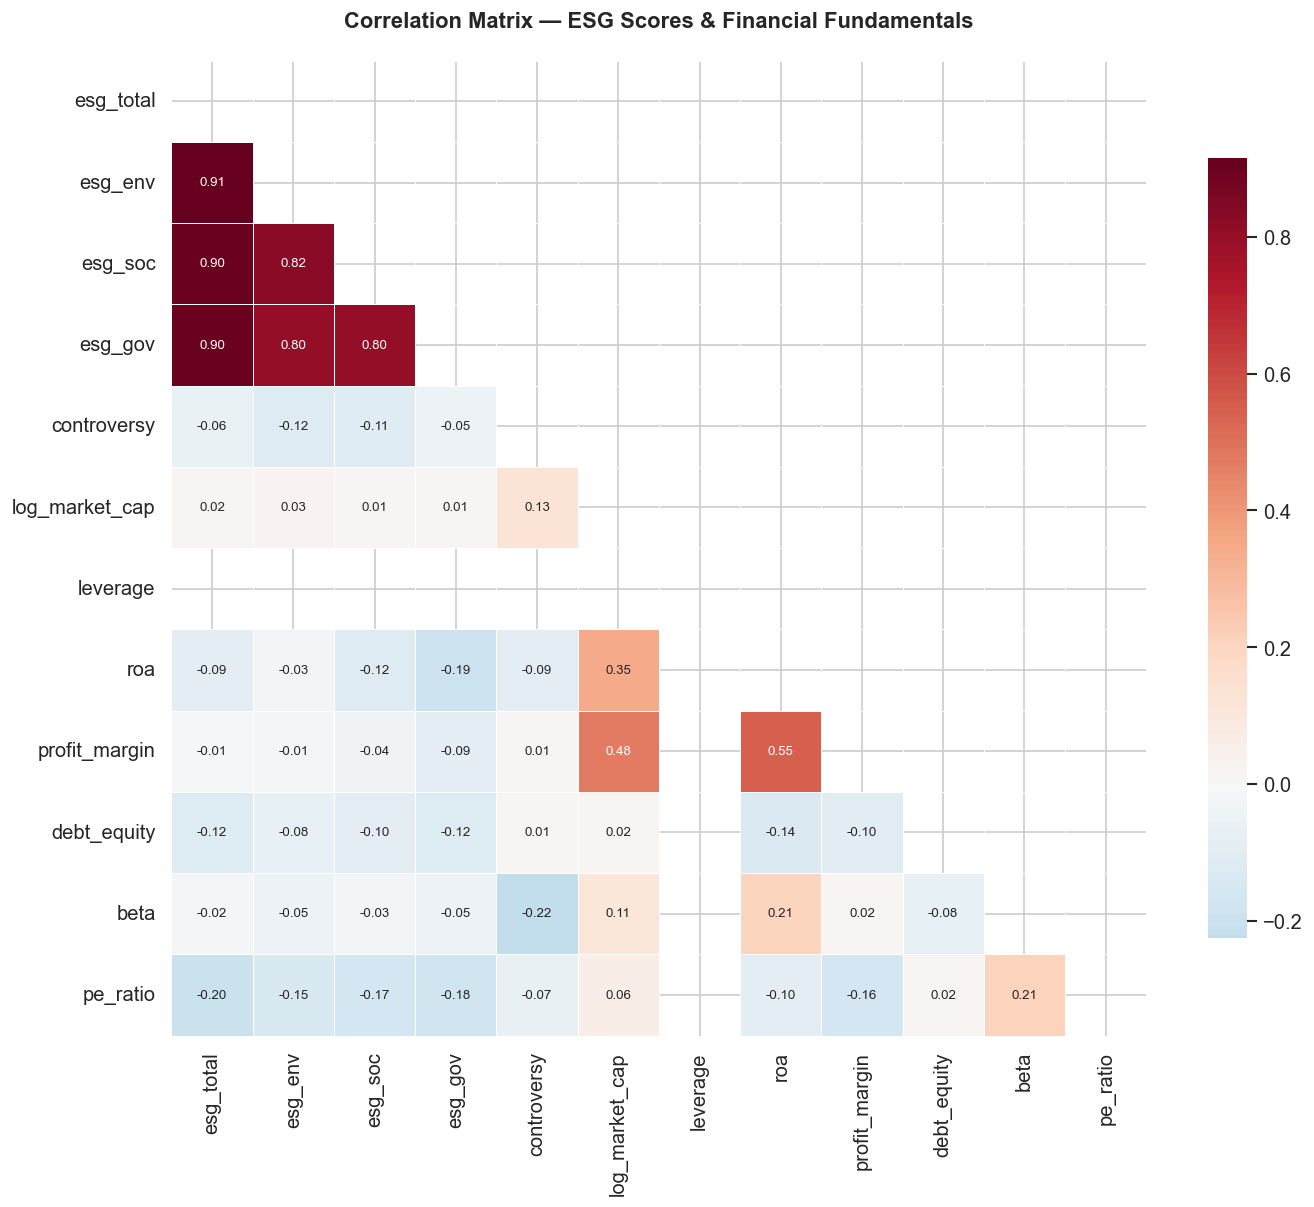

  → Saved: 05_correlation_matrix.png


In [19]:
numeric_cols = ["esg_total", "esg_env", "esg_soc", "esg_gov", "controversy",
                "log_market_cap", "leverage", "roa", "profit_margin",
                "debt_equity", "beta", "pe_ratio"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
ax.set_title("Correlation Matrix — ESG Scores & Financial Fundamentals",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("  → Saved: 05_correlation_matrix.png")


### 5.6 ESG sub-score pair plot


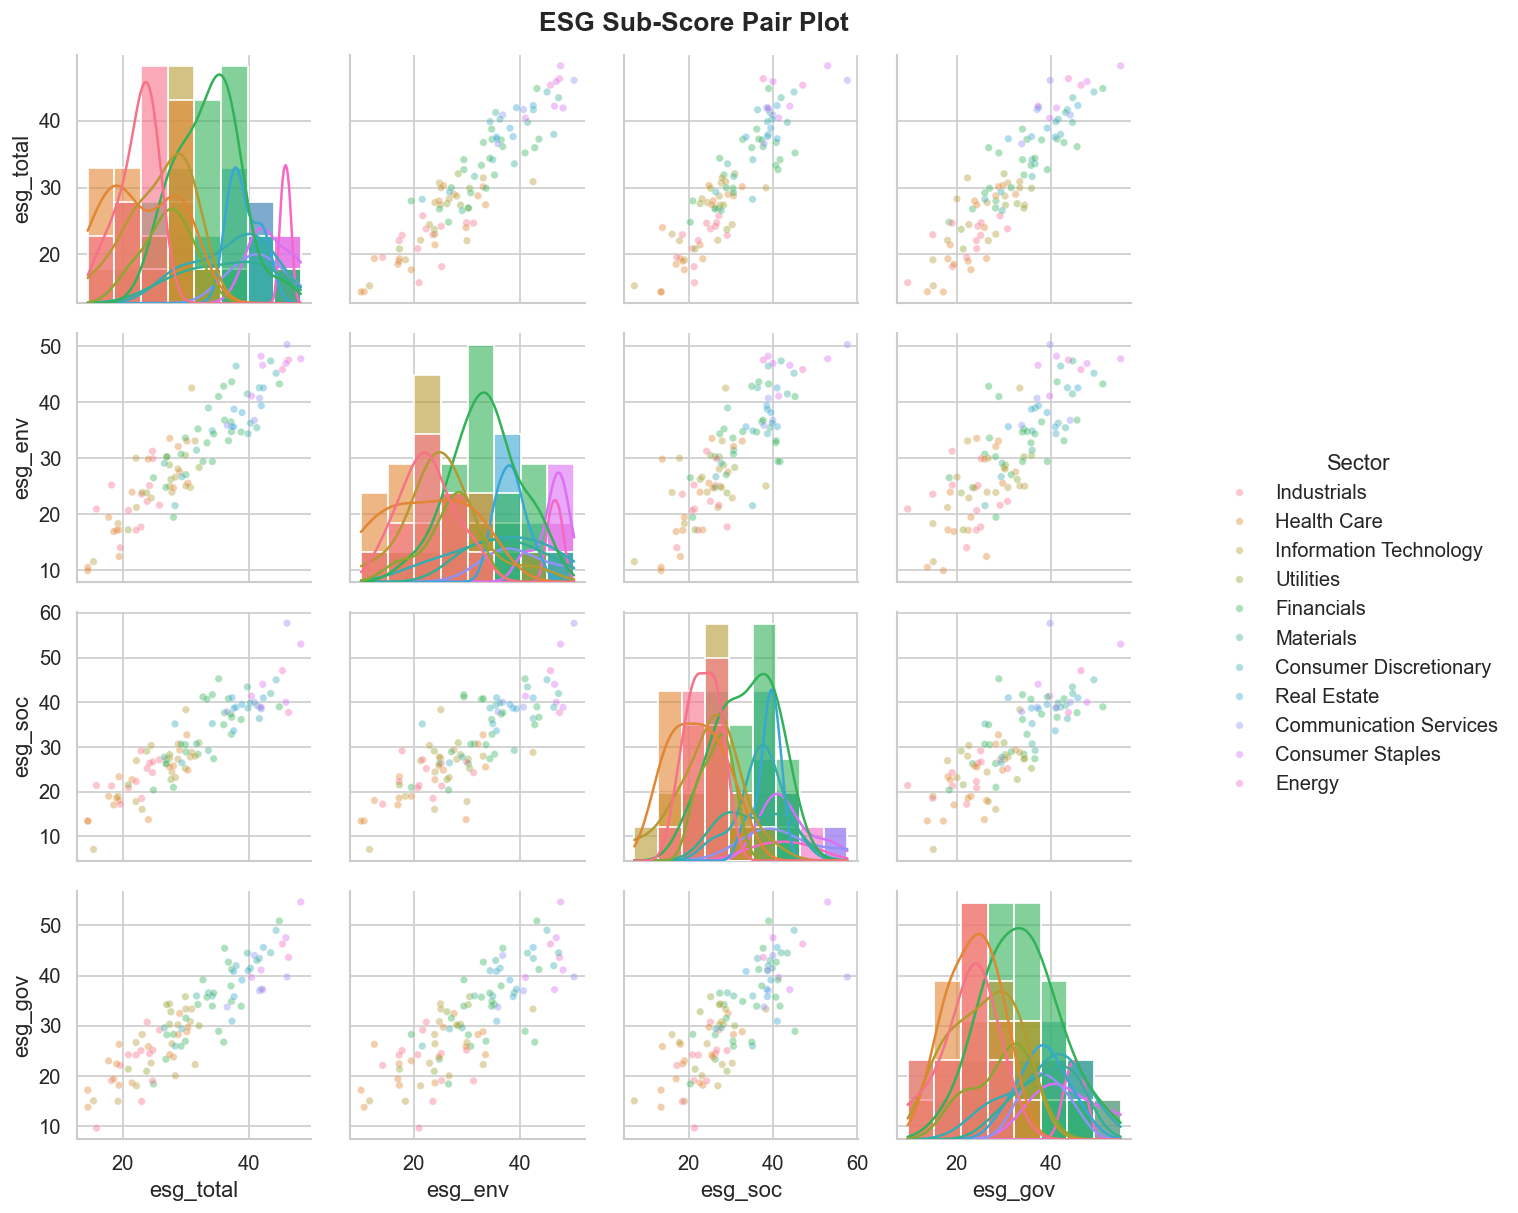

  → Saved: 06_esg_pairplot.png


In [20]:
sub_cols = [c for c in ["esg_total", "esg_env", "esg_soc", "esg_gov"] if c in df.columns]
g = sns.PairGrid(df[sub_cols + ["sector"]].dropna(subset=sub_cols), hue="sector",
                 diag_sharey=False, height=2.5)
g.map_diag(sns.histplot, kde=True, alpha=0.6)
g.map_offdiag(sns.scatterplot, alpha=0.4, s=20)
g.add_legend(title="Sector", bbox_to_anchor=(1.05, 0.5))
g.figure.suptitle("ESG Sub-Score Pair Plot", fontweight="bold", y=1.01)
plt.savefig(f"{OUTPUT_DIR}/06_esg_pairplot.png", bbox_inches="tight")
plt.show()
print("  → Saved: 06_esg_pairplot.png")


### 5.7 Controversy distribution


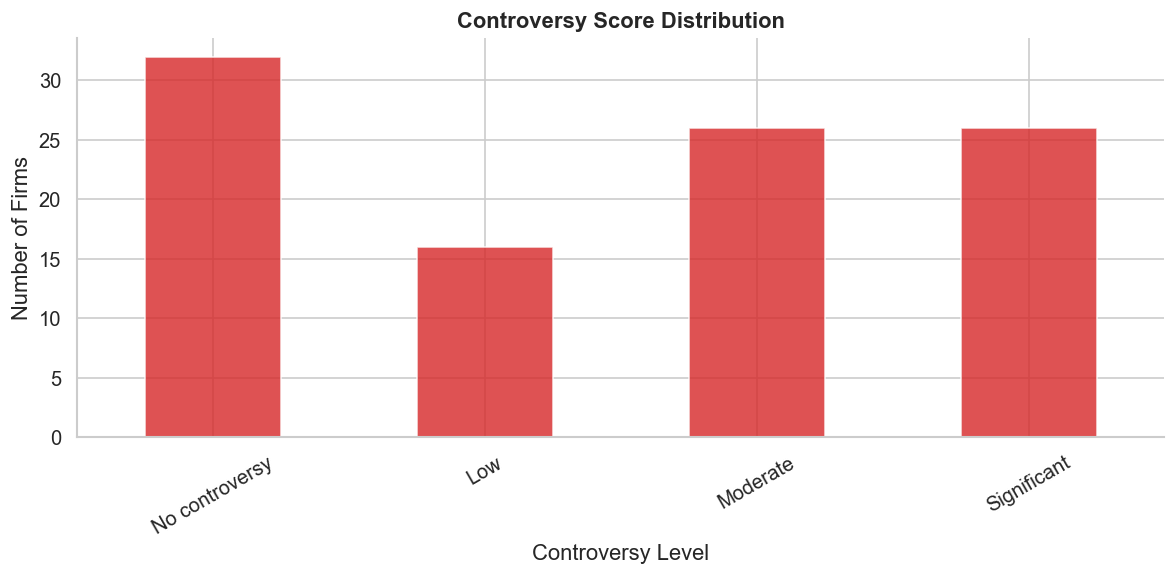

  → Saved: 07_controversy.png


In [21]:
if "controversy" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    controversy_counts = df["controversy"].value_counts().sort_index()
    labels = {0: "No controversy", 1: "Low", 2: "Moderate", 3: "Significant", 4: "High", 5: "Severe"}
    controversy_counts.index = [labels.get(int(i), str(i)) for i in controversy_counts.index]
    controversy_counts.plot(kind="bar", ax=ax, color="#d62728", alpha=0.8, edgecolor="white")
    ax.set_title("Controversy Score Distribution", fontweight="bold")
    ax.set_xlabel("Controversy Level")
    ax.set_ylabel("Number of Firms")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/07_controversy.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 07_controversy.png")
else:
    print("  (Skipping controversy plot — column not present.)")


## 6. Preliminary inconsistency proxy (OLS / Ridge)

Regress total ESG on fundamentals and sector dummies; residuals serve as a simple over- vs under-rating proxy before a full ML model.


In [29]:
print("\n[6/6] Computing preliminary OLS-based ESG inconsistency proxy...")

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

target_col = "esg_total"
feature_cols = [c for c in ["log_market_cap", "leverage", "roa", "profit_margin", "beta"] if c in df.columns]

base = [target_col, "sector"] + feature_cols
base = list(dict.fromkeys(c for c in base if c in df.columns))
work = df.reindex(columns=base).copy()
work = work.dropna(subset=[target_col, "sector"])

for c in feature_cols:
    if c not in work.columns:
        continue
    med = work[c].median()
    work[c] = work[c].fillna(0.0 if pd.isna(med) else med)

feature_cols = [c for c in feature_cols if c in work.columns]
if feature_cols:
    var_ok = [c for c in feature_cols if work[c].nunique(dropna=True) > 1]
    if len(var_ok) < len(feature_cols):
        feature_cols = var_ok if var_ok else feature_cols[:1]

analysis_df = work[[target_col, "sector"] + feature_cols].copy()
OLS_OK = False
r2 = float("nan")

if len(analysis_df) == 0:
    print("  Skipping OLS: no rows with esg_total and sector.")
elif len(feature_cols) == 0:
    print("  Skipping OLS: no fundamental feature columns in df.")
else:
    enc = pd.get_dummies(analysis_df, columns=["sector"], drop_first=True)
    X = enc.drop(columns=[target_col])
    y = enc[target_col]
    min_rows = max(15, X.shape[1] + 3)
    if len(y) < min_rows:
        print(f"  Skipping OLS: {len(y)} complete firms but need ≥{min_rows} for {X.shape[1]} regressors.")
    else:
        pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
        pipe.fit(X, y)
        y_pred = pipe.predict(X)
        resid = np.asarray(y, dtype=float) - y_pred
        analysis_df["esg_predicted_ols"] = y_pred
        analysis_df["inconsistency_proxy"] = resid
        r2 = pipe.score(X, y)
        OLS_OK = True
        print(f"  OLS baseline R² (in-sample): {r2:.3f}")
        print(f"  Inconsistency proxy — mean: {resid.mean():.4f}, std: {resid.std():.3f}")

if not OLS_OK:
    analysis_df["esg_predicted_ols"] = np.nan
    analysis_df["inconsistency_proxy"] = np.nan



[6/6] Computing preliminary OLS-based ESG inconsistency proxy...
  OLS baseline R² (in-sample): 0.725
  Inconsistency proxy — mean: -0.0000, std: 4.412


### Inconsistency distribution and top firms


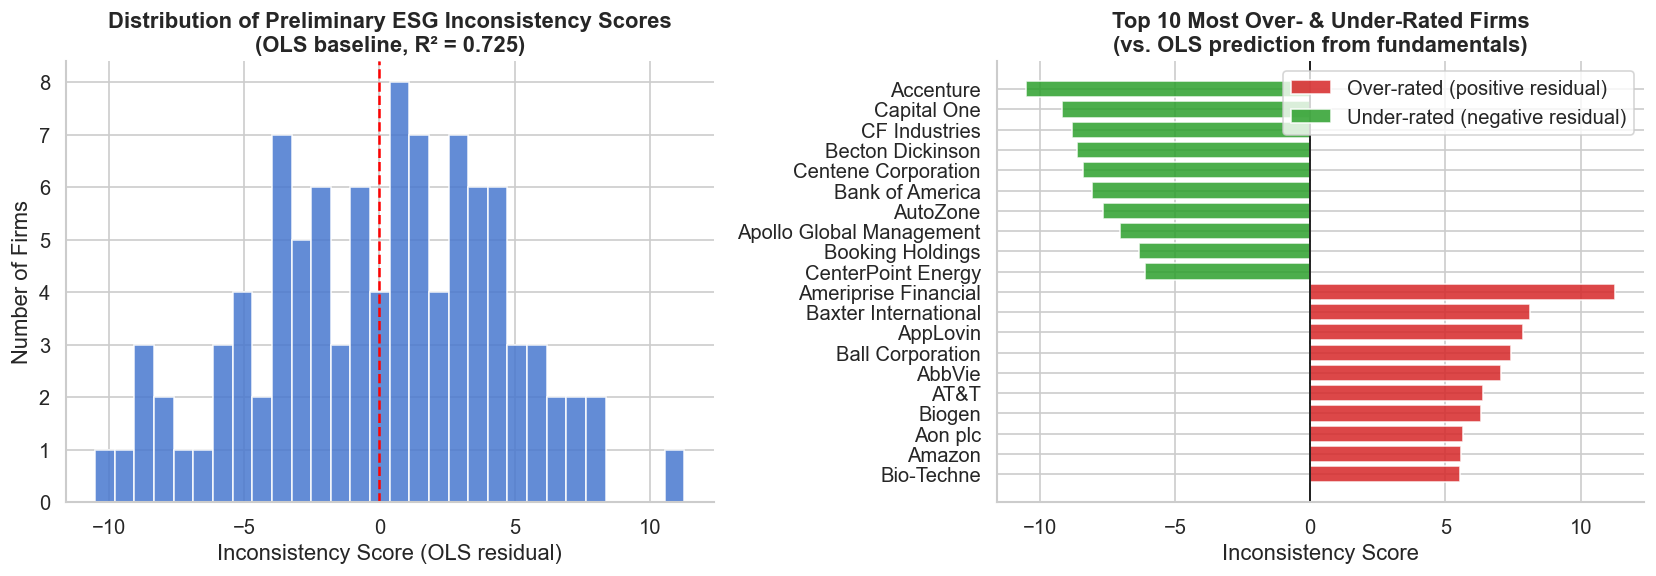

  → Saved: 08_inconsistency_proxy.png


In [30]:
if not OLS_OK:
    print("  Skipping inconsistency plots (OLS not run — see message above).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(analysis_df["inconsistency_proxy"], bins=30, color="#4878CF", edgecolor="white", alpha=0.85)
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
    axes[0].set_xlabel("Inconsistency Score (OLS residual)")
    axes[0].set_ylabel("Number of Firms")
    axes[0].set_title(f"Distribution of Preliminary ESG Inconsistency Scores\n(OLS baseline, R² = {r2:.3f})", fontweight="bold")

    analysis_df = analysis_df.copy()
    analysis_df["company"] = df.loc[analysis_df.index, "company"]
    top_over  = analysis_df.nlargest(10, "inconsistency_proxy")[["company", "inconsistency_proxy", "esg_total"]]
    top_under = analysis_df.nsmallest(10, "inconsistency_proxy")[["company", "inconsistency_proxy", "esg_total"]]

    axes[1].barh(top_over["company"].values[::-1],
                 top_over["inconsistency_proxy"].values[::-1],
                 color="#d62728", alpha=0.85, label="Over-rated (positive residual)")
    axes[1].barh(top_under["company"].values[::-1],
                 top_under["inconsistency_proxy"].values[::-1],
                 color="#2ca02c", alpha=0.85, label="Under-rated (negative residual)")
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_xlabel("Inconsistency Score")
    axes[1].set_title("Top 10 Most Over- & Under-Rated Firms\n(vs. OLS prediction from fundamentals)", fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/08_inconsistency_proxy.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 08_inconsistency_proxy.png")


### Mean inconsistency by sector


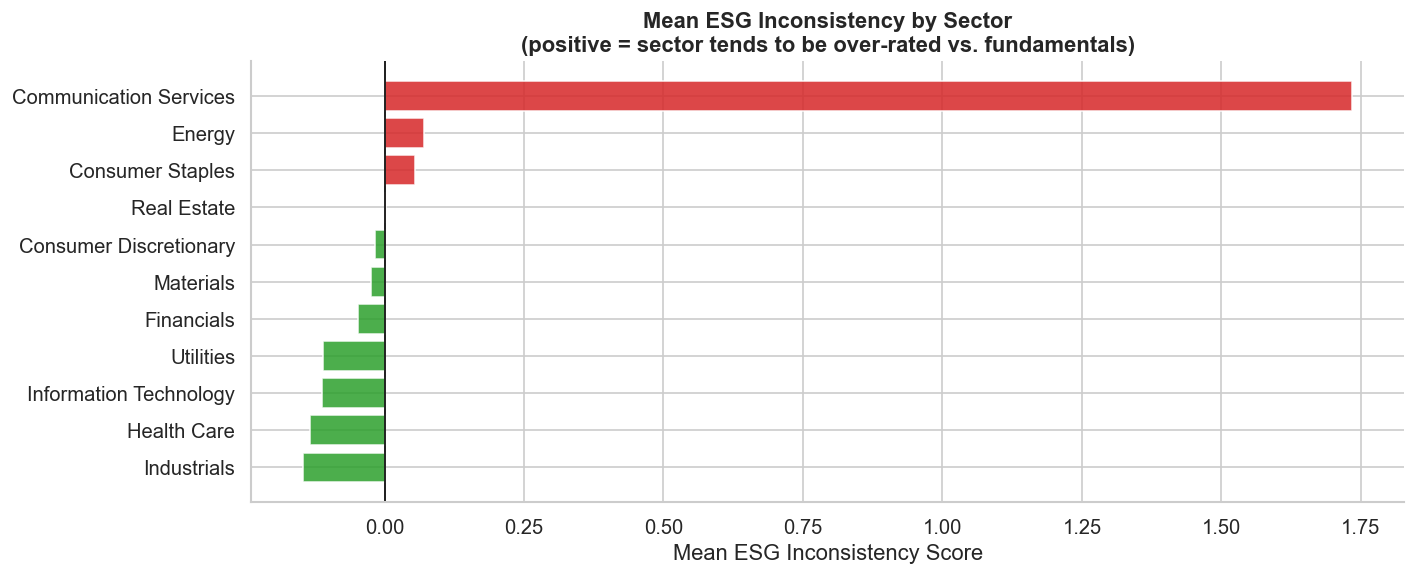

  → Saved: 09_inconsistency_by_sector.png


In [31]:
if not OLS_OK:
    print("  Skipping inconsistency-by-sector plot (OLS not run).")
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    sector_incons = analysis_df.groupby("sector")["inconsistency_proxy"].mean().sort_values()
    colors = ["#d62728" if v > 0 else "#2ca02c" for v in sector_incons.values]
    ax.barh(sector_incons.index, sector_incons.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Mean ESG Inconsistency Score")
    ax.set_title("Mean ESG Inconsistency by Sector\n(positive = sector tends to be over-rated vs. fundamentals)",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/09_inconsistency_by_sector.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 09_inconsistency_by_sector.png")


## 7. Summary and export


In [32]:
print("\n" + "=" * 70)
print("EDA COMPLETE — Summary Statistics")
print("=" * 70)
print(f"\n  Sample size        : {len(df)} firms")
print(f"  Sectors covered    : {df['sector'].nunique()}")
print(f"  ESG coverage rate  : {(~df['esg_total'].isna()).mean():.1%}")
print(f"\n  ESG Total Score    : mean = {df['esg_total'].mean():.1f}, "
      f"std = {df['esg_total'].std():.1f}, "
      f"range = [{df['esg_total'].min():.1f}, {df['esg_total'].max():.1f}]")
if OLS_OK and pd.notna(r2):
    print(f"  OLS Baseline R²    : {r2:.3f}  (target for ML model: > 0.30)")
else:
    print("  OLS Baseline R²    : N/A (insufficient data or OLS skipped)")
print(f"\n  Plots saved in     : ./{OUTPUT_DIR}/")
print(f"  Files: {sorted(os.listdir(OUTPUT_DIR))}")

df.to_csv(f"{OUTPUT_DIR}/master_dataset.csv")
if OLS_OK:
    out_inc = analysis_df[["esg_total", "esg_predicted_ols", "inconsistency_proxy", "sector", "company"]].copy()
    out_inc.to_csv(f"{OUTPUT_DIR}/inconsistency_scores.csv")
    print(f"\n  Data exported to   : ./{OUTPUT_DIR}/master_dataset.csv")
    print(f"                       ./{OUTPUT_DIR}/inconsistency_scores.csv")
else:
    print(f"\n  Data exported to   : ./{OUTPUT_DIR}/master_dataset.csv")
    print("  (inconsistency_scores.csv skipped — OLS not run)")
print("\nDone! Review the plots above and the exported CSVs for your thesis.")



EDA COMPLETE — Summary Statistics

  Sample size        : 100 firms
  Sectors covered    : 11
  ESG coverage rate  : 100.0%

  ESG Total Score    : mean = 30.8, std = 8.5, range = [14.4, 48.3]
  OLS Baseline R²    : 0.725  (target for ML model: > 0.30)

  Plots saved in     : ./eda_outputs/
  Files: ['01_missing_data.png', '02_esg_distributions.png', '03_esg_by_sector.png', '05_correlation_matrix.png', '06_esg_pairplot.png', '07_controversy.png', '08_inconsistency_proxy.png', '09_inconsistency_by_sector.png']

  Data exported to   : ./eda_outputs/master_dataset.csv
                       ./eda_outputs/inconsistency_scores.csv

Done! Review the plots above and the exported CSVs for your thesis.
